In [2]:
import pandas as pd
df = pd.read_csv("loan_prediction.csv")
print(df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [4]:
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df.fillna({
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Dependents': df['Dependents'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'Credit_History': df['Credit_History'].mode()[0],
    'LoanAmount': df['LoanAmount'].median(),
    'Loan_Amount_Term': df['Loan_Amount_Term'].median()
}, inplace=True)


In [8]:
df = df.drop('Loan_ID', axis=1)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])  # Target



In [ ]:
df = pd.get_dummies(df, columns=['Dependents', 'Property_Area'], drop_first=True)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=42)

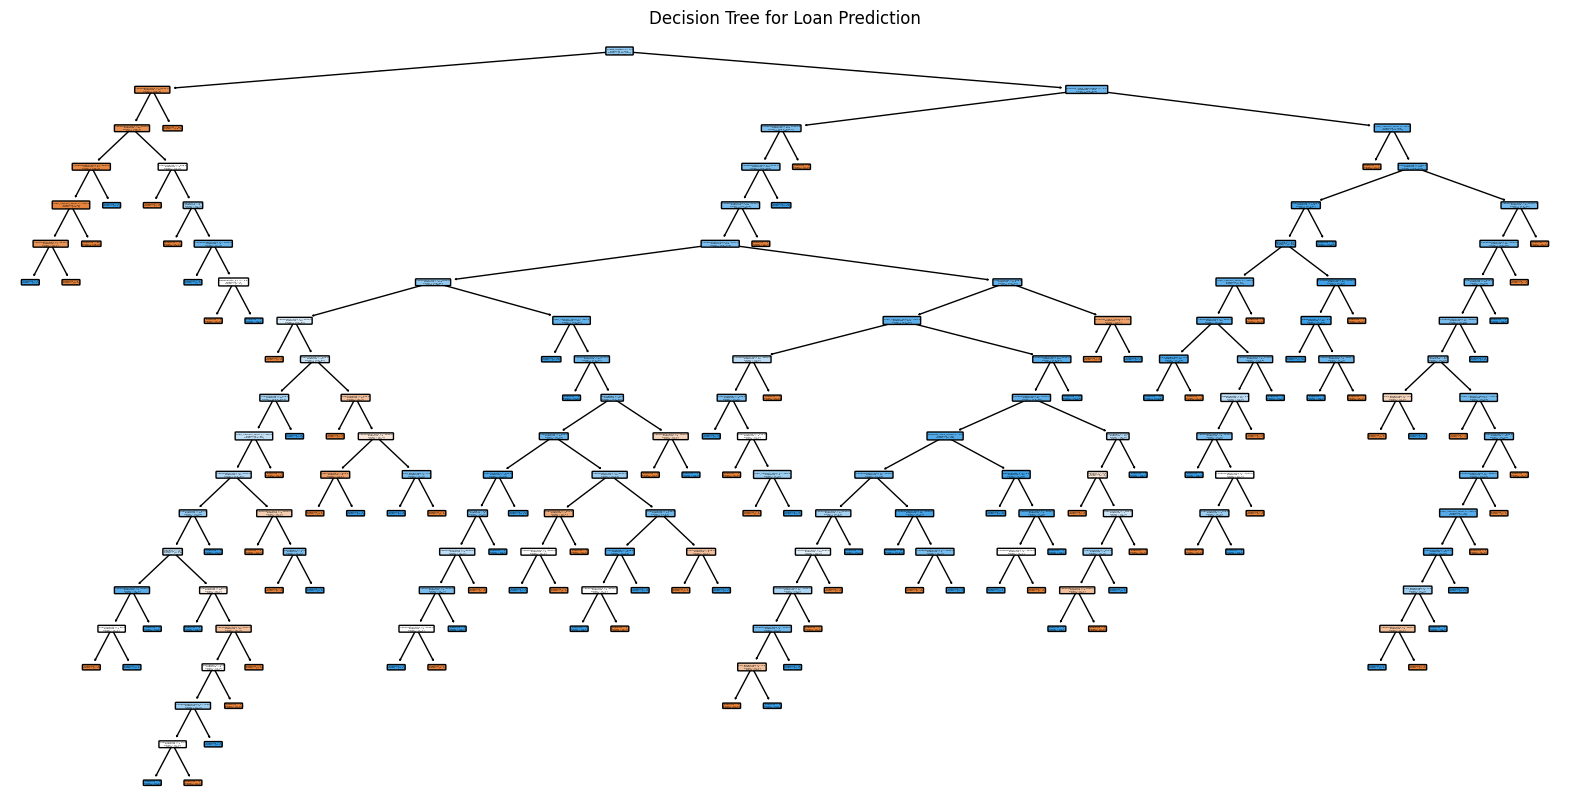

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    impurity=False   # hides entropy
)
plt.title("Decision Tree for Loan Prediction")
plt.show()


In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7235772357723578
              precision    recall  f1-score   support

           0       0.62      0.53      0.57        43
           1       0.77      0.82      0.80        80

    accuracy                           0.72       123
   macro avg       0.69      0.68      0.69       123
weighted avg       0.72      0.72      0.72       123



In [15]:
# Hardcoded new applicant
new_sample = pd.DataFrame([{
    'Gender': 1,                # Male
    'Married': 1,               # Yes
    'Education': 1,             # Graduate
    'Self_Employed': 0,         # No
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Dependents_1': 0,
    'Dependents_2': 1,
    'Dependents_3+': 0,
    'Property_Area_Semiurban': 1,
    'Property_Area_Urban': 0
}])

# Align columns to match training data
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)
# Predict loan status
prediction = dt.predict(new_sample)

# Print result
print("Loan Status Prediction:", "Approved" if prediction[0] == 1 else "Rejected")

Loan Status Prediction: Approved
